In [9]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display graphs inside notebook
%matplotlib inline

# Set plot style
sns.set_style("whitegrid")


In [11]:
# Load the dataset

df = pd.read_csv("UberDataset.csv")

# Display first 5 rows
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [12]:
# Shape of dataset
print("Rows and Columns:", df.shape)

# Dataset information
df.info()

# Summary statistics
df.describe()

Rows and Columns: (1156, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   str    
 1   END_DATE    1155 non-null   str    
 2   CATEGORY    1155 non-null   str    
 3   START       1155 non-null   str    
 4   STOP        1155 non-null   str    
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    str    
dtypes: float64(1), str(6)
memory usage: 63.3 KB


,MILES
count,1156.000000
mean,21.115398
std,359.299007
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,12204.700000


In [13]:
# Missing values

df.isnull().sum()

START_DATE      0
END_DATE        1
CATEGORY        1
START           1
STOP            1
MILES           0
PURPOSE       503
dtype: int64

In [14]:
# Remove rows where important columns are missing

df.dropna(subset=["START_DATE", "END_DATE", "CATEGORY", "START", "STOP"], inplace=True)

In [15]:
df.isnull().sum()

START_DATE      0
END_DATE        0
CATEGORY        0
START           0
STOP            0
MILES           0
PURPOSE       502
dtype: int64

In [16]:
# Fill missing PURPOSE values

df["PURPOSE"] = df["PURPOSE"].fillna("Unknown")

In [20]:
# Convert object to datetime
df["START_DATE"] = pd.to_datetime(
    df["START_DATE"],
    format="%m/%d/%Y %H:%M",
    errors="coerce"
)

df["END_DATE"] = pd.to_datetime(
    df["END_DATE"],
    format="%m/%d/%Y %H:%M",
    errors="coerce"
)

# Remove rows where date conversion failed
df.dropna(subset=["START_DATE", "END_DATE"], inplace=True)

In [21]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
23,2016-01-13 13:54:00,2016-01-13 14:07:00,Business,Downtown,Gulfton,11.2,Meeting
24,2016-01-13 15:00:00,2016-01-13 15:28:00,Business,Gulfton,Downtown,11.8,Meeting
25,2016-01-14 16:29:00,2016-01-14 17:05:00,Business,Houston,Houston,21.9,Customer Visit
26,2016-01-14 21:39:00,2016-01-14 21:45:00,Business,Eagan Park,Jamestown Court,3.9,Errand/Supplies
27,2016-01-15 00:41:00,2016-01-15 01:01:00,Business,Morrisville,Cary,8.0,Errand/Supplies


In [22]:
print(df["START_DATE"].tail(10))

1145   2016-12-30 10:15:00
1146   2016-12-30 11:31:00
1147   2016-12-30 15:41:00
1148   2016-12-30 16:45:00
1149   2016-12-30 23:06:00
1150   2016-12-31 01:07:00
1151   2016-12-31 13:24:00
1152   2016-12-31 15:03:00
1153   2016-12-31 21:32:00
1154   2016-12-31 22:08:00
Name: START_DATE, dtype: datetime64[us]


In [23]:
print(df.isnull().sum())

START_DATE    0
END_DATE      0
CATEGORY      0
START         0
STOP          0
MILES         0
PURPOSE       0
dtype: int64


In [24]:
# Extract useful information

df["Hour"] = df["START_DATE"].dt.hour
df["Day"] = df["START_DATE"].dt.day
df["Month"] = df["START_DATE"].dt.month
df["Weekday"] = df["START_DATE"].dt.day_name()

# Trip Duration (minutes)

df["Duration"] = (
    df["END_DATE"] - df["START_DATE"]
).dt.total_seconds() / 60

In [25]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,Hour,Day,Month,Weekday,Duration
23,2016-01-13 13:54:00,2016-01-13 14:07:00,Business,Downtown,Gulfton,11.2,Meeting,13,13,1,Wednesday,13.0
24,2016-01-13 15:00:00,2016-01-13 15:28:00,Business,Gulfton,Downtown,11.8,Meeting,15,13,1,Wednesday,28.0
25,2016-01-14 16:29:00,2016-01-14 17:05:00,Business,Houston,Houston,21.9,Customer Visit,16,14,1,Thursday,36.0
26,2016-01-14 21:39:00,2016-01-14 21:45:00,Business,Eagan Park,Jamestown Court,3.9,Errand/Supplies,21,14,1,Thursday,6.0
27,2016-01-15 00:41:00,2016-01-15 01:01:00,Business,Morrisville,Cary,8.0,Errand/Supplies,0,15,1,Friday,20.0


In [26]:
print(df.info())

print(df.isnull().sum())

<class 'pandas.DataFrame'>
Index: 734 entries, 23 to 1154
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  734 non-null    datetime64[us]
 1   END_DATE    734 non-null    datetime64[us]
 2   CATEGORY    734 non-null    str           
 3   START       734 non-null    str           
 4   STOP        734 non-null    str           
 5   MILES       734 non-null    float64       
 6   PURPOSE     734 non-null    str           
 7   Hour        734 non-null    int32         
 8   Day         734 non-null    int32         
 9   Month       734 non-null    int32         
 10  Weekday     734 non-null    str           
 11  Duration    734 non-null    float64       
dtypes: datetime64[us](2), float64(2), int32(3), str(5)
memory usage: 65.9 KB
None
START_DATE    0
END_DATE      0
CATEGORY      0
START         0
STOP          0
MILES         0
PURPOSE       0
Hour          0
Day           0
Month     

# Exploratory Data Analysis

In [27]:
# Display first five rows
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,Hour,Day,Month,Weekday,Duration
23,2016-01-13 13:54:00,2016-01-13 14:07:00,Business,Downtown,Gulfton,11.2,Meeting,13,13,1,Wednesday,13.0
24,2016-01-13 15:00:00,2016-01-13 15:28:00,Business,Gulfton,Downtown,11.8,Meeting,15,13,1,Wednesday,28.0
25,2016-01-14 16:29:00,2016-01-14 17:05:00,Business,Houston,Houston,21.9,Customer Visit,16,14,1,Thursday,36.0
26,2016-01-14 21:39:00,2016-01-14 21:45:00,Business,Eagan Park,Jamestown Court,3.9,Errand/Supplies,21,14,1,Thursday,6.0
27,2016-01-15 00:41:00,2016-01-15 01:01:00,Business,Morrisville,Cary,8.0,Errand/Supplies,0,15,1,Friday,20.0


In [28]:
# Display last five rows
df.tail()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,Hour,Day,Month,Weekday,Duration
1150,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Kar?chi,Kar?chi,0.7,Meeting,1,31,12,Saturday,7.0
1151,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Kar?chi,Unknown Location,3.9,Temporary Site,13,31,12,Saturday,18.0
1152,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting,15,31,12,Saturday,35.0
1153,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site,21,31,12,Saturday,18.0
1154,2016-12-31 22:08:00,2016-12-31 23:51:00,Business,Gampaha,Ilukwatta,48.2,Temporary Site,22,31,12,Saturday,103.0


In [29]:
# Statistical Summary
df.describe()

,START_DATE,END_DATE,MILES,Hour,Day,Month,Duration
count,734,734,734.000000,734.000000,734.000000,734.000000,734.000000
mean,2016-07-25 20:39:53.623978,2016-07-25 21:05:22.643051,11.417984,14.528610,21.880109,7.091281,25.483651
min,2016-01-13 13:54:00,2016-01-13 14:07:00,0.500000,0.000000,13.000000,1.000000,0.000000
25%,2016-04-04 00:50:00,2016-04-04 01:24:00,3.000000,11.000000,18.000000,3.250000,10.000000
50%,2016-07-27 23:02:00,2016-07-27 23:17:30,6.000000,15.000000,22.000000,7.000000,17.000000
75%,2016-10-28 15:11:15,2016-10-28 16:53:15,11.075000,18.000000,27.000000,10.000000,29.000000
max,2016-12-31 22:08:00,2016-12-31 23:51:00,310.300000,23.000000,31.000000,12.000000,336.000000
std,NaN,NaN,24.033821,4.515382,5.188592,3.567873,30.844001


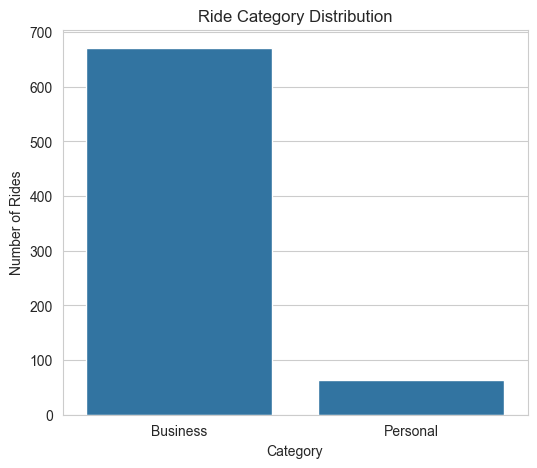

In [43]:
#Ride Category Distribution
plt.figure(figsize=(6,5))

sns.countplot(x='CATEGORY', data=df)

plt.title("Ride Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Rides")

plt.show()

In [33]:
# insight Most Uber rides in the dataset are Business trips

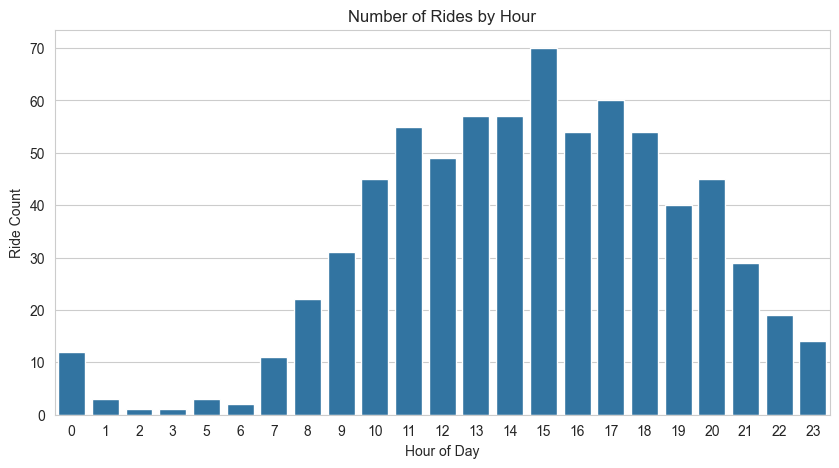

In [42]:
#Ride Distribution by Hour (Peak Hours)
plt.figure(figsize=(10,5))

sns.countplot(x='Hour', data=df)

plt.title("Number of Rides by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Ride Count")

plt.show()

In [38]:
#Insight

#This graph helps identify peak travel hours during the day

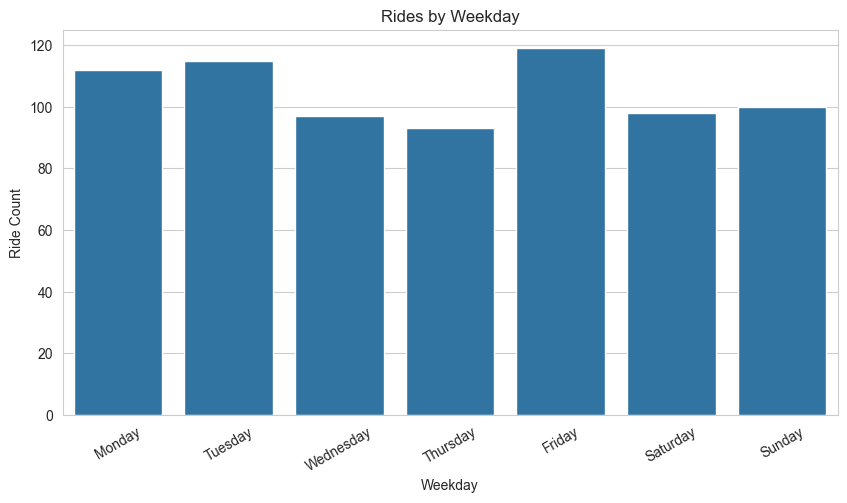

In [41]:
# Ride Distribution by Weekday
weekday_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

plt.figure(figsize=(10,5))

sns.countplot(
    x="Weekday",
    data=df,
    order=weekday_order
)

plt.xticks(rotation=30)

plt.title("Rides by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Ride Count")

plt.show()

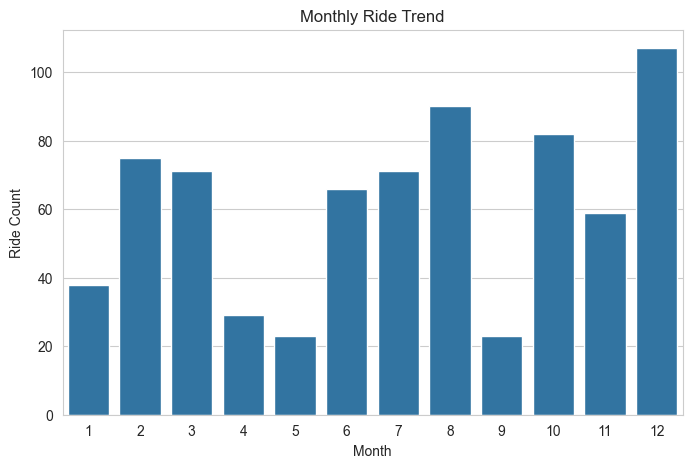

In [45]:
#Monthly Ride Trend
plt.figure(figsize=(8,5))

sns.countplot(x="Month", data=df)

plt.title("Monthly Ride Trend")
plt.xlabel("Month")
plt.ylabel("Ride Count")

plt.show()

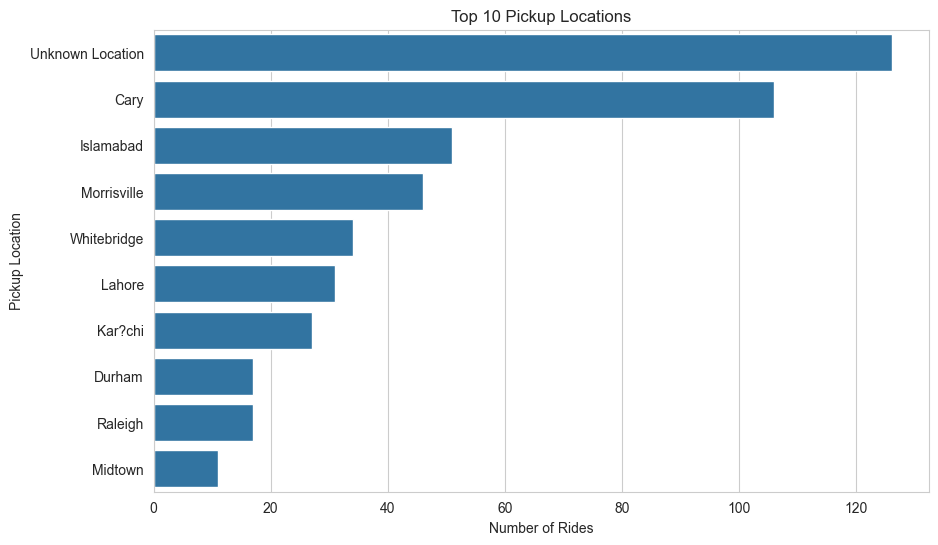

In [46]:
#Top 10 pickup location
top_start = df["START"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_start.values,
    y=top_start.index
)

plt.title("Top 10 Pickup Locations")
plt.xlabel("Number of Rides")
plt.ylabel("Pickup Location")

plt.show()

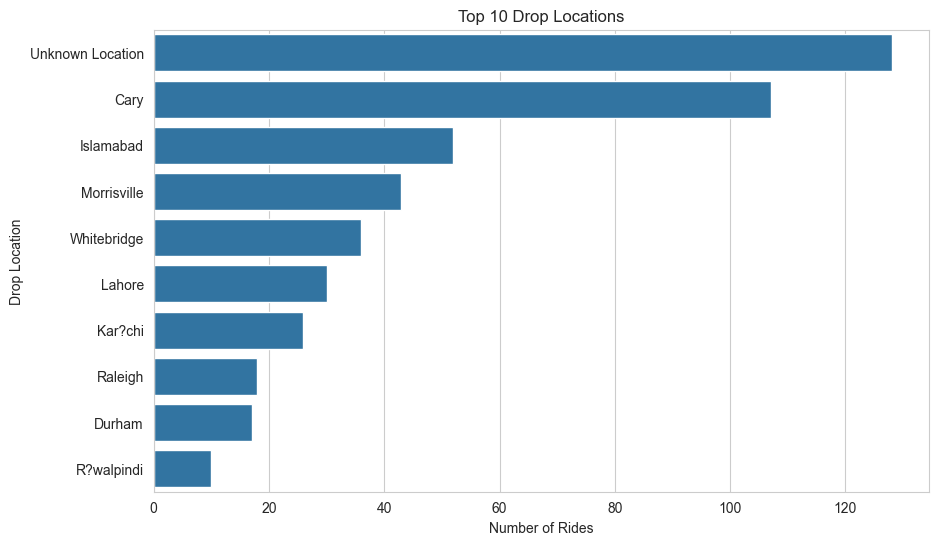

In [47]:
#Top 10 Drop location
top_stop = df["STOP"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_stop.values,
    y=top_stop.index
)

plt.title("Top 10 Drop Locations")
plt.xlabel("Number of Rides")
plt.ylabel("Drop Location")

plt.show()

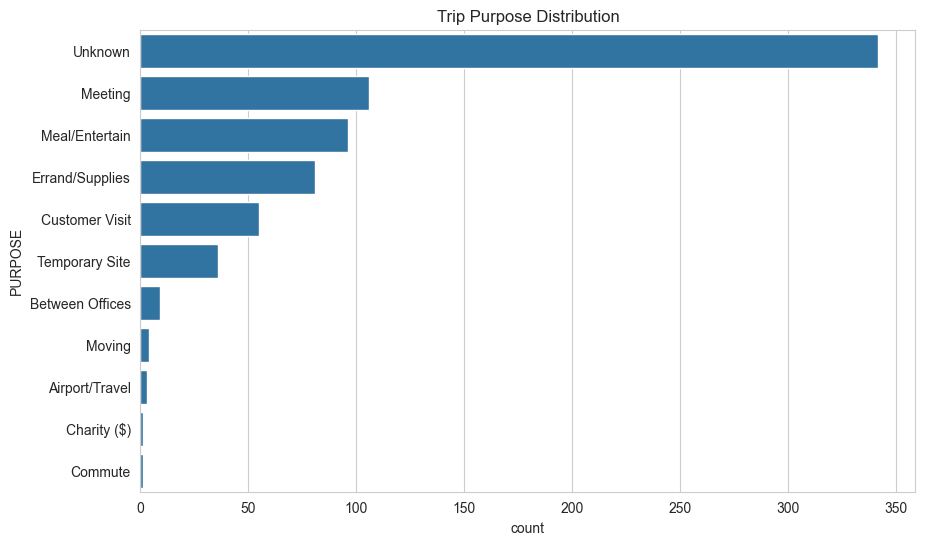

In [49]:
#Trip purpose distribution
plt.figure(figsize=(10,6))

sns.countplot(
    y="PURPOSE",
    data=df,
    order=df["PURPOSE"].value_counts().index
)

plt.title("Trip Purpose Distribution")

plt.show()

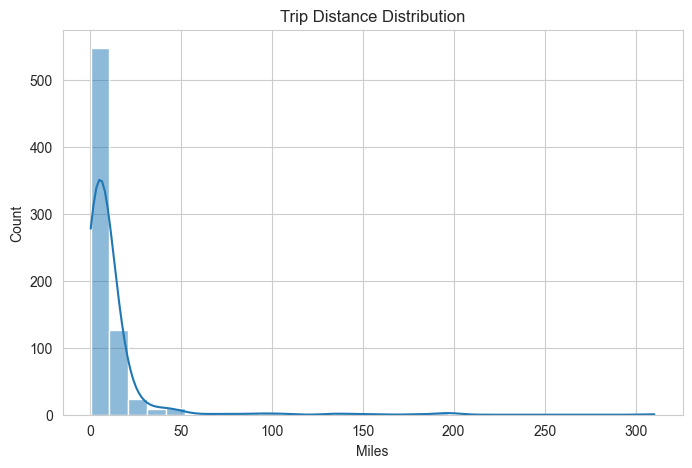

In [50]:
# Miles Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["MILES"], bins=30, kde=True)

plt.title("Trip Distance Distribution")
plt.xlabel("Miles")

plt.show()

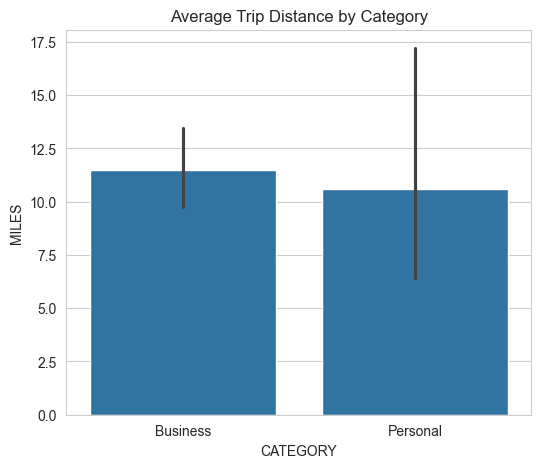

In [52]:
#Average Distance by Category
plt.figure(figsize=(6,5))

sns.barplot(
    x="CATEGORY",
    y="MILES",
    data=df
)

plt.title("Average Trip Distance by Category")

plt.show()

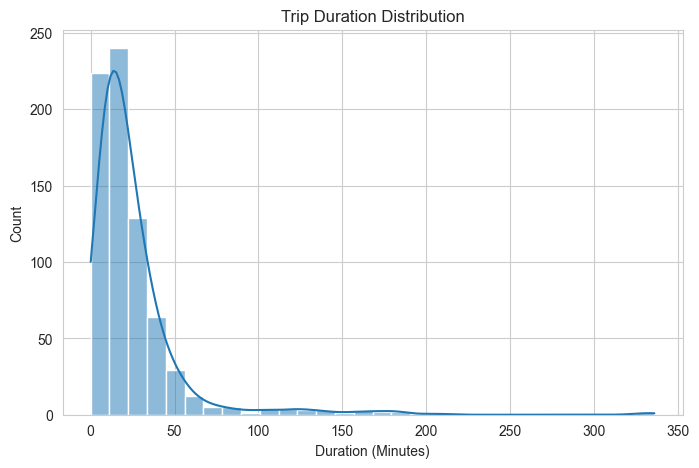

In [53]:
#Trip Duration Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Duration"], bins=30, kde=True)

plt.title("Trip Duration Distribution")
plt.xlabel("Duration (Minutes)")

plt.show()

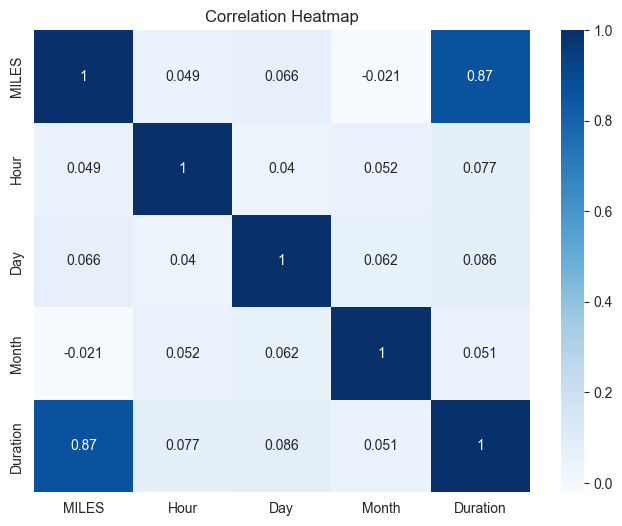

In [54]:
#Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

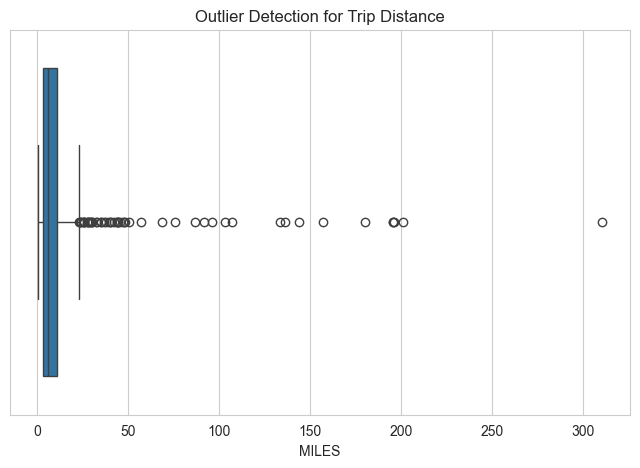

In [55]:
#Boxplot of Trip Distance
plt.figure(figsize=(8,5))

sns.boxplot(x=df["MILES"])

plt.title("Outlier Detection for Trip Distance")

plt.show()

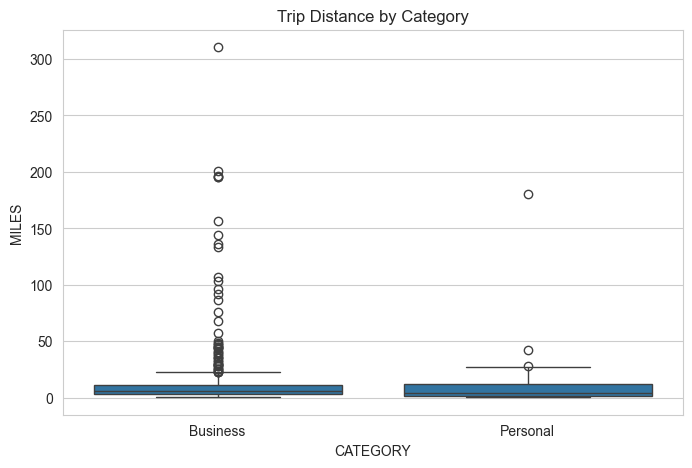

In [56]:
#Business vs Personal Ride Distance
plt.figure(figsize=(8,5))

sns.boxplot(
    x="CATEGORY",
    y="MILES",
    data=df
)

plt.title("Trip Distance by Category")

plt.show()

##### Business rides are more frequent than Personal rides.
##### Most trips occur during working hours.
##### Ride demand varies across weekdays and months.
##### Certain pickup and drop locations dominate the dataset.
##### Most trips cover short distances, with a few long-distance outliers.
##### The "Unknown" purpose appears frequently because many rides have missing purpose information in the original dataset.